# Estimation du Prix  au m² 


**Objectif** : Construire un modèle de Machine Learning pour estimer le **prix au m² (DH)** d'un bien immobilier à partir de ses caractéristiques :
- **Caractéristiques du bien** : type de bien, état, condition / zonage
- **Variables géomarketing (POI)** : proximité des écoles, banques, santé, commerces, transports, mer, parcs, nuisances, axes routiers
- **Variables socio-démographiques** : densité de population, taux d'activité, chômage, niveau d'études, taille de ménage


**Méthodologie suivie** :
1. Préparation et nettoyage
2. Découpage Train/Test et standardisation
3. Entraînement de **4 modèles** : Decision Tree, Random Forest, LightGBM, XGBoost
4. Optimisation des hyperparamètres 
6. Interprétation par **SHAP** (XGBoost)

---

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, json
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# === Paramètres  ===
RANDOM_STATE = 42
N_SPLITS     = 5
N_TRIALS     = 50   

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement et préparation des données

Étapes : filtrage des prix aberrants, imputation médiane, encodage catégoriel, log-transformation de la cible.

In [4]:
import os
os.getcwd()
os.chdir("c:\\Users\\del\\Desktop\\prix-immobilier-evaluation\\estimation_prix_m2")

In [8]:
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import LabelEncoder

# =========================
# Chargement des données
# =========================
df = pd.read_csv("data_finale.csv")

# Filtrage
df = df[df["Prix Terrain au m² (DH)"] >= 100].copy()

cible = "Prix Terrain au m² (DH)"

# =========================
# 1) Imputation médiane
# =========================
for col in df.select_dtypes(include="number").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# =========================
# 2) Encodage catégoriel
# =========================
cols_cat = ["Type de bien", "État", "Condition / Zonage"]

# dictionnaire pour stocker les encodeurs
label_encoders = {}

for col in cols_cat:
    
    # remplacer NaN
    df[col] = df[col].fillna("Aucune").astype(str)

    # créer encoder
    le = LabelEncoder()

    # fit + transform
    df[col] = le.fit_transform(df[col])

    # sauvegarder dans le dictionnaire
    label_encoders[col] = le

    # sauvegarder chaque encoder séparément
    #joblib.dump(le, f"model_artifacts/{col}.pkl")

# sauvegarder tous les encodeurs ensemble
joblib.dump(label_encoders, "model_artifacts/all_label_encoders.pkl")

print("LabelEncoders sauvegardés avec succès.")

# =========================
# 3) X / y avec log-transform
# =========================
features_to_drop = [
    cible,
    "Préfecture",
    "Arrondissement",
    "Code Zone",
    "Zone déchiffrée"
]

X = df.drop(columns=features_to_drop, errors="ignore")

y_raw = df[cible].values

# transformation logarithmique
y = np.log1p(y_raw)

# =========================
# Infos
# =========================
print(f"X : {X.shape} | y : {y.shape}")

print(f"Skewness y_raw  : {pd.Series(y_raw).skew():.2f}")
print(f"Skewness log(y) : {pd.Series(y).skew():.2f} → distribution quasi-normale")

LabelEncoders sauvegardés avec succès.
X : (1473, 44) | y : (1473,)
Skewness y_raw  : 2.47
Skewness log(y) : 0.37 → distribution quasi-normale


In [12]:
all_encoders = joblib.load("model_artifacts/all_label_encoders.pkl")
for col, le in all_encoders.items():
    print(f"Colonne : {col} | Classes : {le.classes_}")

Colonne : Type de bien | Classes : ['Appartement' 'Appartement sécurisé' 'Maison' 'Terrain ZI' 'Terrain ZV'
 'Villa']
Colonne : État | Classes : ['Ancien' 'Loti' 'Neuf' 'Récent']
Colonne : Condition / Zonage | Classes : ['< à R+10' '< à R+5' '<= 1000 m2' '<= R+5' '<= à R+2' '<= à R+3'
 '<= à R+4' '<= à R+5' '> 1000 m2' '> à R+2' '> à R+3' '> à R+4' '> à R+5'
 '>= à R+10' '>= à R+5' 'Aucune'
 'CC-MA10                                     PT : 12 000/PC'
 'CS-AC13                                     PT : 12 000/PC'
 'CS-AC15                                         PT : 12 000/PC'
 'CS-HH18                                    PT : 10 000/PC'
 'CS-HH3                                                                                PT : 16 000/PC'
 'PT : 10 000/¨PC' 'R+5' 'Si ST < 1000 m2' 'Si ST < 600 m2'
 'Si ST <= 200 m2' 'Si ST > 200 m2' 'Si ST >= 1000 m2' 'Si ST >= 600 m2'
 'Totaux']


In [5]:
df = pd.read_csv("data_finale.csv")
df = df[df["Prix Terrain au m² (DH)"] >= 100].copy()

cible = "Prix Terrain au m² (DH)"

# 1) Imputation médiane 
for col in df.select_dtypes(include="number").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# 2) Encodage catégoriel
cols_cat = ["Type de bien", "État", "Condition / Zonage"]
for col in cols_cat:
    df[col] = df[col].fillna("INCONNU").astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

# 3) X / y avec log-transformation
features_to_drop = [cible, "Préfecture", "Arrondissement", "Code Zone", "Zone déchiffrée"]
X = df.drop(columns=features_to_drop, errors="ignore")
y_raw = df[cible].values
y = np.log1p(y_raw)

print(f"X : {X.shape} | y : {y.shape}")
print(f"Skewness y_raw  : {pd.Series(y_raw).skew():.2f}")
print(f"Skewness log(y) : {pd.Series(y).skew():.2f}  → distribution quasi-normale")

X : (1473, 44) | y : (1473,)
Skewness y_raw  : 2.47
Skewness log(y) : 0.37  → distribution quasi-normale


## 3. Outil d'évaluation par Cross-Validation

`evaluate_cv` retourne pour chaque modèle :
- R² **moyen ± std** sur 5 folds (en DH/m², après `expm1`)
- RMSE **moyen ± std** en DH/m²
- **gap train ↔ CV** = signal d'overfitting 

In [16]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(model_factory, X, y, cv=kf, label=""):
    """Évalue un modèle en CV ; renvoie un dict de métriques (échelle DH/m²)."""
    r2_tr, r2_te, rmse_te = [], [], []

    for tr_idx, te_idx in cv.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = model_factory()
        model.fit(X_tr, y_tr)

        pred_tr = np.expm1(model.predict(X_tr))
        pred_te = np.expm1(model.predict(X_te))
        true_tr = np.expm1(y_tr)
        true_te = np.expm1(y_te)

        r2_tr.append(r2_score(true_tr, pred_tr))
        r2_te.append(r2_score(true_te, pred_te))
        rmse_te.append(np.sqrt(mean_squared_error(true_te, pred_te)))

    return {
        "label":           label,
        "r2_train_mean":   np.mean(r2_tr),
        "r2_test_mean":    np.mean(r2_te),
        "r2_test_std":     np.std(r2_te),
        "rmse_test_mean":  np.mean(rmse_te),
        "rmse_test_std":   np.std(rmse_te),
        "gap":             np.mean(r2_tr) - np.mean(r2_te),
        "r2_test_per_fold": r2_te,
    }

def overfit_tag(gap):
    if gap > 0.10:  return " overfitting fort"
    if gap > 0.05:  return "modéré"
    return " OK"

def print_eval(res):
    print(f"  R² train       : {res['r2_train_mean']:.4f}")
    print(f"  R² CV          : {res['r2_test_mean']:.4f} ± {res['r2_test_std']:.4f}")
    print(f"  RMSE CV        : {res['rmse_test_mean']:.0f} ± {res['rmse_test_std']:.0f} DH/m²")
    print(f"  Gap train-CV   : {res['gap']:.4f}  ({overfit_tag(res['gap'])})")

## 4. Baseline

Point de départ : 4 modèles avec des hyperparamètres initiées.

In [26]:
baseline_factories = {
    "DecisionTree": lambda: DecisionTreeRegressor(
        max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": lambda: LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=RANDOM_STATE, verbosity=-1),
    "XGBoost": lambda: XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
}

baseline_results = {}
for name, factory in baseline_factories.items():
    print(f"\n--- {name} ---")
    res = evaluate_cv(factory, X, y, label=name)
    baseline_results[name] = res
    print_eval(res)


--- DecisionTree ---
  R² train       : 0.7291
  R² CV          : 0.6173 ± 0.0692
  RMSE CV        : 4259 ± 473 DH/m²
  Gap train-CV   : 0.1118  ( overfitting fort)

--- RandomForest ---
  R² train       : 0.8072
  R² CV          : 0.7089 ± 0.0262
  RMSE CV        : 3737 ± 411 DH/m²
  Gap train-CV   : 0.0983  (modéré)

--- LightGBM ---
  R² train       : 0.8705
  R² CV          : 0.7326 ± 0.0526
  RMSE CV        : 3559 ± 444 DH/m²
  Gap train-CV   : 0.1379  ( overfitting fort)

--- XGBoost ---
  R² train       : 0.9030
  R² CV          : 0.7662 ± 0.0276
  RMSE CV        : 3329 ± 211 DH/m²
  Gap train-CV   : 0.1368  ( overfitting fort)


### 4.1 Synthèse de la baseline

In [6]:
def results_to_df(results):
    return pd.DataFrame([
        {
            "Modèle":        r["label"],
            "R² CV":         round(r["r2_test_mean"], 4),
            "Std CV":        round(r["r2_test_std"], 4),
            "RMSE CV":       round(r["rmse_test_mean"], 0),
            "Gap train-CV":  round(r["gap"], 4),
        }
        for r in results.values()
    ]).sort_values("R² CV", ascending=False).reset_index(drop=True)

df_baseline = results_to_df(baseline_results)
df_baseline

,Modèle,R² CV,Std CV,RMSE CV,Gap train-CV
0,XGBoost,0.7662,0.0276,3329.0,0.1368
1,LightGBM,0.7326,0.0526,3559.0,0.1379
2,RandomForest,0.7089,0.0262,3737.0,0.0983
3,DecisionTree,0.6173,0.0692,4259.0,0.1118


## 5. Optimisation bayésienne avec Optuna

In [ ]:
def cv_score_optuna(model_class, params):
    """R² moyen en KFold ."""
    scores = []
    for tr, te in kf.split(X, y):
        m = model_class(**params).fit(X.iloc[tr], y[tr])
        pred = np.expm1(m.predict(X.iloc[te]))
        true = np.expm1(y[te])
        scores.append(r2_score(true, pred))
    return float(np.mean(scores))

def objective_dt(trial):
    return cv_score_optuna(DecisionTreeRegressor, {
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 50),
        "max_features":      trial.suggest_float("max_features", 0.4, 1.0),
        "random_state":      RANDOM_STATE,
    })

def objective_rf(trial):
    return cv_score_optuna(RandomForestRegressor, {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 4, 14),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 3, 30),
        "max_features":     trial.suggest_float("max_features", 0.3, 1.0),
        "n_jobs": -1, "random_state": RANDOM_STATE,
    })

def objective_lgbm(trial):
    return cv_score_optuna(LGBMRegressor, {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "num_leaves":        trial.suggest_int("num_leaves", 8, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE, "verbosity": -1,
    })

def objective_xgb(trial):
    return cv_score_optuna(XGBRegressor, {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "random_state": RANDOM_STATE, "verbosity": 0, "n_jobs": -1,
    })

In [9]:
# Lancement Optuna
studies = {}
objectives = {
    "DecisionTree": objective_dt,
    "RandomForest": objective_rf,
    "LightGBM":     objective_lgbm,
    "XGBoost":      objective_xgb,
}

for name, obj in objectives.items():
    print(f"\nOptuna → {name} ({N_TRIALS} essais)…")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(obj, n_trials=N_TRIALS, show_progress_bar=False)
    studies[name] = study
    print(f"  → meilleur R² CV = {study.best_value:.4f}")


Optuna → DecisionTree (50 essais)…
  → meilleur R² CV = 0.6907

Optuna → RandomForest (50 essais)…
  → meilleur R² CV = 0.7247

Optuna → LightGBM (50 essais)…
  → meilleur R² CV = 0.7921

Optuna → XGBoost (50 essais)…
  → meilleur R² CV = 0.7991


## 6. Évaluation finale des modèles optimisés

In [27]:
def make_factory(model_class, params):
    return lambda: model_class(**params)

best_factories = {
    "DecisionTree": make_factory(DecisionTreeRegressor,
        {**studies["DecisionTree"].best_params, "random_state": RANDOM_STATE}),
    "RandomForest": make_factory(RandomForestRegressor,
        {**studies["RandomForest"].best_params, "n_jobs": -1, "random_state": RANDOM_STATE}),
    "LightGBM": make_factory(LGBMRegressor,
        {**studies["LightGBM"].best_params, "random_state": RANDOM_STATE, "verbosity": -1}),
    "XGBoost": make_factory(XGBRegressor,
        {**studies["XGBoost"].best_params, "random_state": RANDOM_STATE, "verbosity": 0, "n_jobs": -1}),
}

final_results = {}
for name, factory in best_factories.items():
    print(f"\n--- {name} (Optuna) ---")
    res = evaluate_cv(factory, X, y, label=name)
    final_results[name] = res
    print_eval(res)


--- DecisionTree (Optuna) ---
  R² train       : 0.7823
  R² CV          : 0.6907 ± 0.0593
  RMSE CV        : 3810 ± 237 DH/m²
  Gap train-CV   : 0.0916  (modéré)

--- RandomForest (Optuna) ---
  R² train       : 0.8414
  R² CV          : 0.7247 ± 0.0342
  RMSE CV        : 3626 ± 386 DH/m²
  Gap train-CV   : 0.1166  ( overfitting fort)

--- LightGBM (Optuna) ---
  R² train       : 0.8879
  R² CV          : 0.7921 ± 0.0188
  RMSE CV        : 3152 ± 303 DH/m²
  Gap train-CV   : 0.0958  (modéré)

--- XGBoost (Optuna) ---
  R² train       : 0.8988
  R² CV          : 0.7991 ± 0.0269
  RMSE CV        : 3085 ± 224 DH/m²
  Gap train-CV   : 0.0997  (modéré)


## 7. Sélection du modèle le plus performant & stable

In [18]:
rows = []
for name in best_factories:
    r = final_results[name]
    rows.append({
        "Modèle":        name,
        "R² CV":         round(r["r2_test_mean"], 4),
        "Std CV":        round(r["r2_test_std"], 4),
        "Gap train-CV":  round(r["gap"], 4),
        "RMSE CV":       round(r["rmse_test_mean"], 0),
    })

df_final = pd.DataFrame(rows).sort_values("R² CV", ascending=False).reset_index(drop=True)
best_model_name = df_final.iloc[0]["Modèle"]
print(f"Modèle sélectionné : {best_model_name}\n")
df_final

Modèle sélectionné : XGBoost



,Modèle,R² CV,Std CV,Gap train-CV,RMSE CV
0,XGBoost,0.7991,0.0269,0.0997,3085.0
1,LightGBM,0.7921,0.0188,0.0958,3152.0
2,RandomForest,0.7247,0.0342,0.1166,3626.0
3,DecisionTree,0.6907,0.0593,0.0916,3810.0


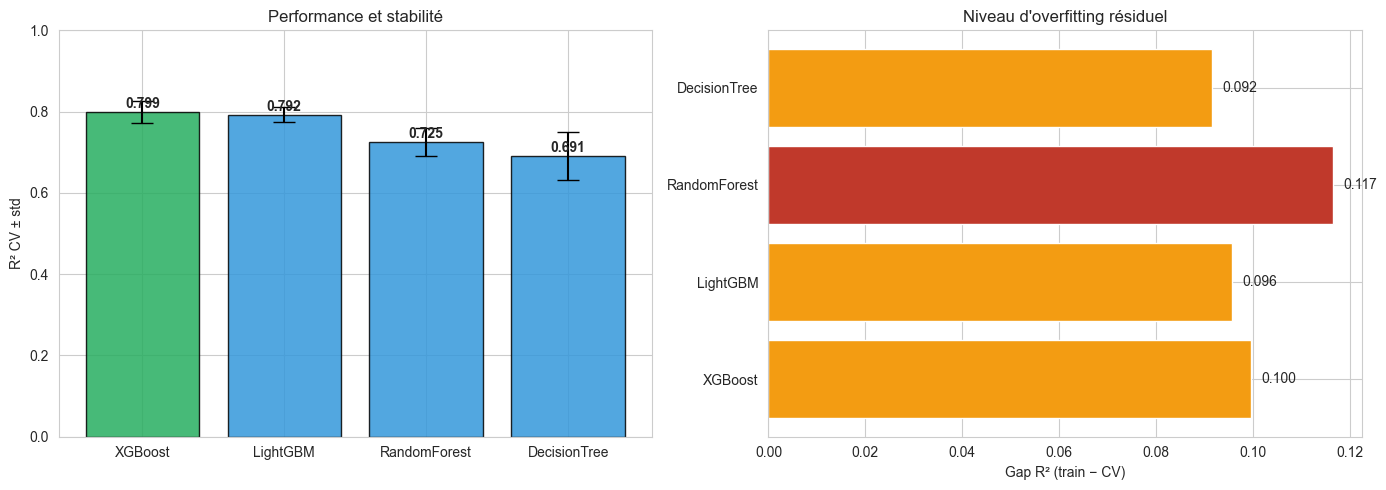

In [19]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) R² ± std
order = df_final["Modèle"].tolist()
means = [final_results[m]["r2_test_mean"] for m in order]
stds  = [final_results[m]["r2_test_std"]  for m in order]
colors = ["#27ae60" if m == best_model_name else "#3498db" for m in order]

axes[0].bar(order, means, yerr=stds, capsize=8, color=colors, edgecolor="black", alpha=0.85)
for i, m in enumerate(means):
    axes[0].text(i, m + 0.01, f"{m:.3f}", ha="center", fontweight="bold")
axes[0].set_ylabel("R² CV ± std")
axes[0].set_title("Performance et stabilité")
axes[0].set_ylim(0, 1)

# (b) Gap train-CV
gaps = [final_results[m]["gap"] for m in order]
gap_colors = ["#27ae60" if g <= 0.05 else "#f39c12" if g <= 0.10 else "#c0392b" for g in gaps]
axes[1].barh(order, gaps, color=gap_colors)
for i, g in enumerate(gaps):
    axes[1].text(g + 0.002, i, f"{g:.3f}", va="center")
axes[1].set_xlabel("Gap R² (train − CV)")
axes[1].set_title("Niveau d'overfitting résiduel")
plt.tight_layout()
plt.show()

## 8. Diagnostic du modèle final

On entraîne le modèle gagnant sur 80% (split classique) pour les graphiques de diagnostic, puis on enchaîne sur l'analyse SHAP.

In [13]:
# Split d'analyse
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_model = best_factories[best_model_name]()
final_model.fit(X_tr, y_tr)

pred_te = np.expm1(final_model.predict(X_te))
true_te = np.expm1(y_te)
residus = true_te - pred_te

print(f"Modèle  : {best_model_name}")
print(f"R²      : {r2_score(true_te, pred_te):.4f}")
print(f"RMSE    : {np.sqrt(mean_squared_error(true_te, pred_te)):.0f} DH/m²")
print(f"MAE     : {mean_absolute_error(true_te, pred_te):.0f} DH/m²")

Modèle  : XGBoost
R²      : 0.7883
RMSE    : 2995 DH/m²
MAE     : 1887 DH/m²


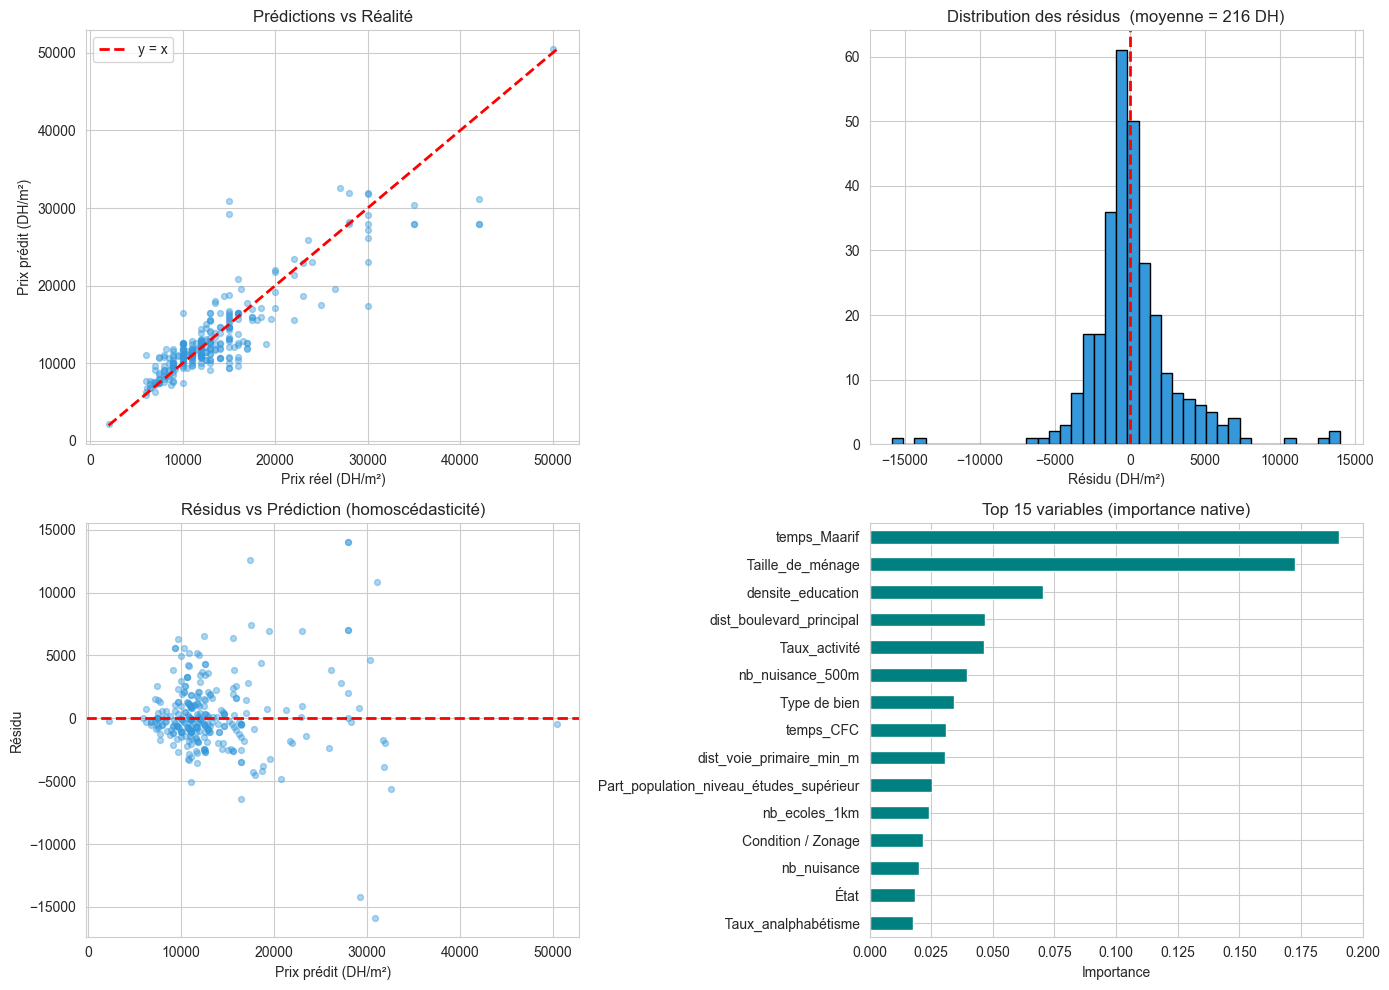

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Prédit vs Réel
axes[0, 0].scatter(true_te, pred_te, alpha=0.4, s=18, color="#3498db")
mn, mx = min(true_te.min(), pred_te.min()), max(true_te.max(), pred_te.max())
axes[0, 0].plot([mn, mx], [mn, mx], "r--", linewidth=2, label="y = x")
axes[0, 0].set_xlabel("Prix réel (DH/m²)")
axes[0, 0].set_ylabel("Prix prédit (DH/m²)")
axes[0, 0].set_title("Prédictions vs Réalité")
axes[0, 0].legend()

# (2) Distribution des résidus
axes[0, 1].hist(residus, bins=40, color="#3498db", edgecolor="black")
axes[0, 1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_title(f"Distribution des résidus  (moyenne = {residus.mean():.0f} DH)")
axes[0, 1].set_xlabel("Résidu (DH/m²)")

# (3) Résidus vs Prédiction
axes[1, 0].scatter(pred_te, residus, alpha=0.4, s=18, color="#3498db")
axes[1, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1, 0].set_xlabel("Prix prédit (DH/m²)")
axes[1, 0].set_ylabel("Résidu")
axes[1, 0].set_title("Résidus vs Prédiction (homoscédasticité)")

# (4) Importance native du modèle
if hasattr(final_model, "feature_importances_"):
    fi = pd.Series(final_model.feature_importances_, index=X.columns)
    fi = fi.sort_values(ascending=True).tail(15)
    fi.plot(kind="barh", ax=axes[1, 1], color="teal")
    axes[1, 1].set_title("Top 15 variables (importance native)")
    axes[1, 1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 9. Interprétation SHAP — pourquoi le modèle prédit ce qu'il prédit ?

In [ ]:
# Calcul des valeurs SHAP sur le set de test
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_te)

# les valeurs SHAP sont en echelle log(prix). Pour les interpreter en DH/m²,
# on  les exponentie multiplicativement : impact_dh ≈ exp(shap) - 1 sur la prediction.
print(f"Valeurs SHAP calculées : shape = {shap_values.shape}")
print(f"Base value (log)        = {explainer.expected_value:.4f}")
print(f"Base value (DH/m²)      ≈ {np.expm1(explainer.expected_value):.0f}")

Valeurs SHAP calculées : shape = (295, 44)
Base value (log)        = 9.4393
Base value (DH/m²)      ≈ 12572


### 9.1 SHAP Summary — importance globale

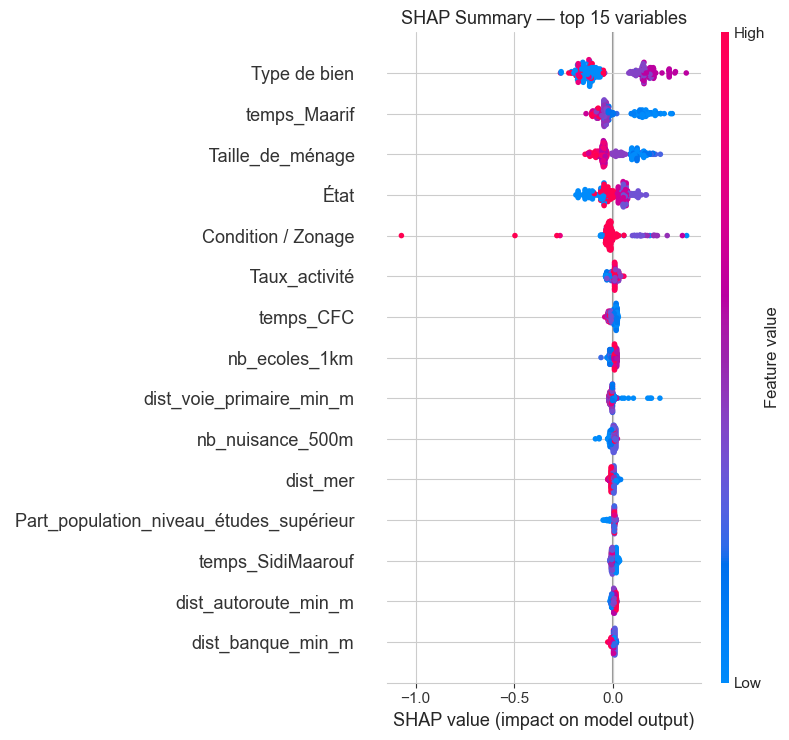

In [21]:
shap.summary_plot(shap_values, X_te, max_display=15, show=False)
plt.title("SHAP Summary — top 15 variables", fontsize=13)
plt.tight_layout()
plt.show()

**types de biens et son état avec condition\zonage impactent énormément le prix**

**temps élevé vers Maarif, CFC baisse du prix alors que l'inverse hausse du prix**

**zones avec taille de ménage plus petits augmentent du prix**

### 9.2 Importance globale 

moyenne des contributions par variable dans la prédiction.

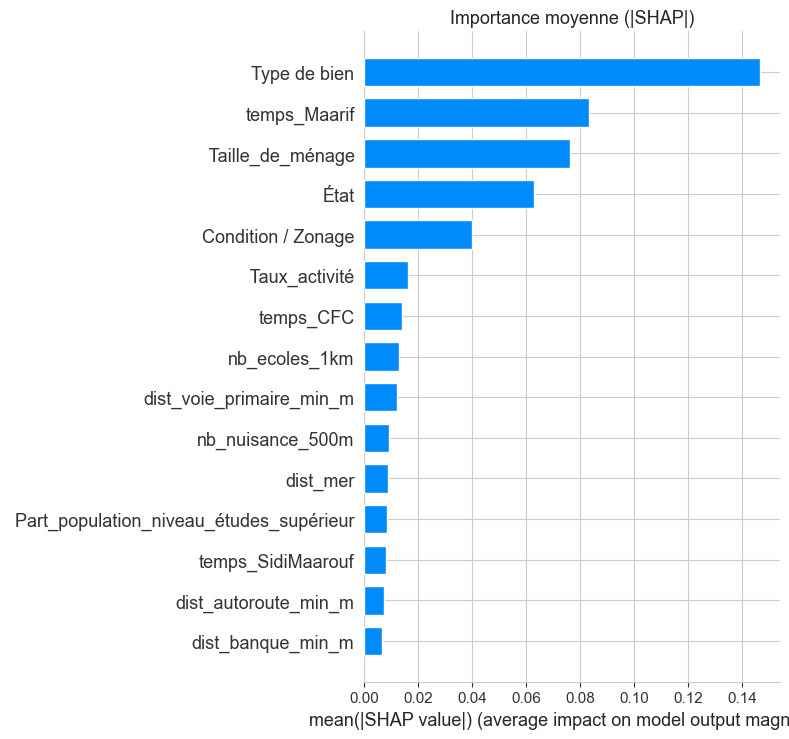

In [28]:
shap.summary_plot(shap_values, X_te, plot_type="bar", max_display=15, show=False)
plt.title("Importance moyenne (|SHAP|)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.3 Dépendances SHAP — comment chaque variable agit

Pour les 4 variables les plus importantes : courbe de l'impact SHAP (la contribution de la variable) en fonction de la valeur de la feature.

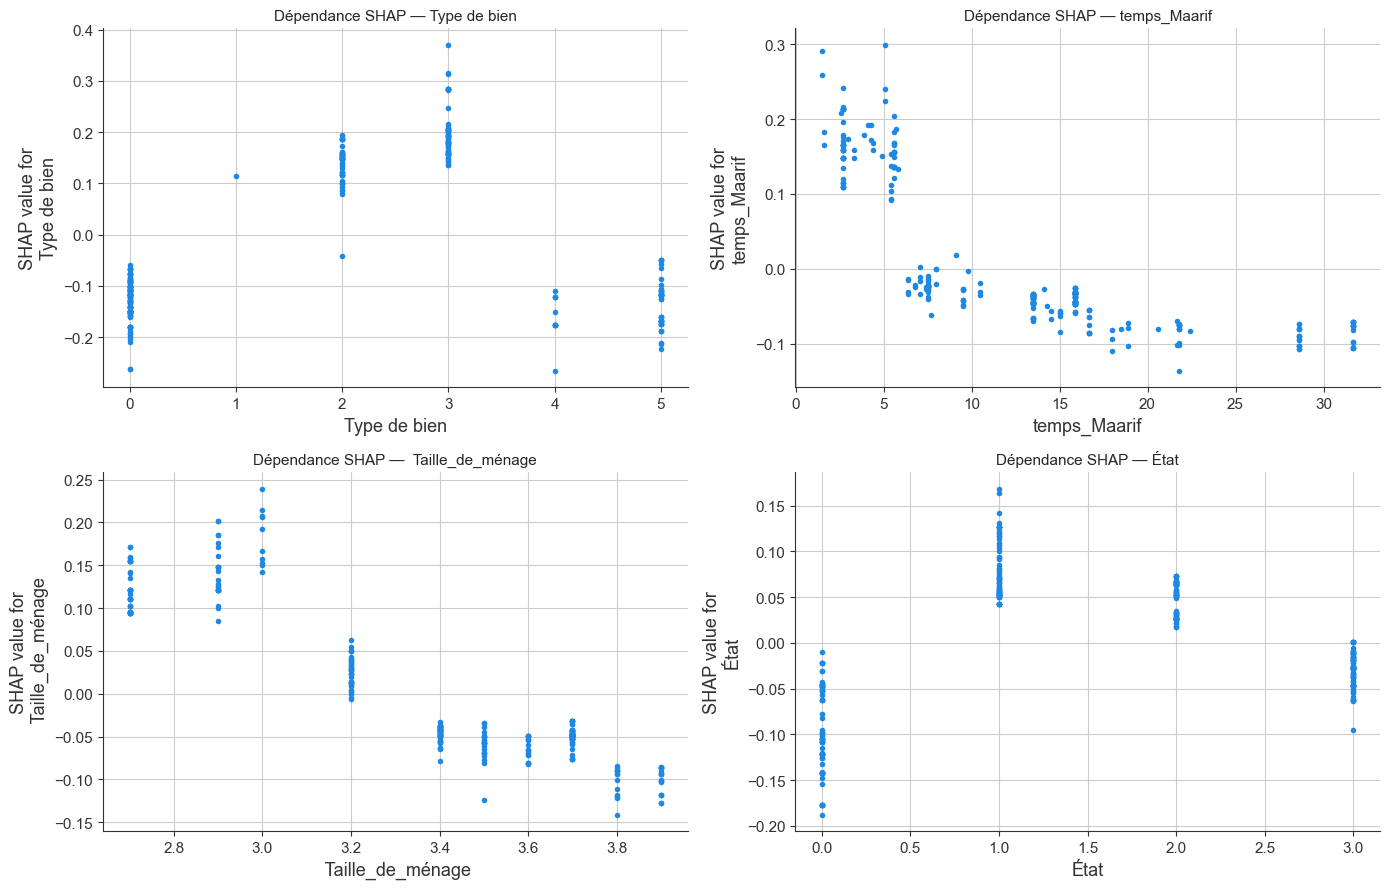

Top 4 features : ['Type de bien', 'temps_Maarif', ' Taille_de_ménage', 'État']


In [23]:
# Top 4 features par |SHAP| moyen
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top4_idx = np.argsort(mean_abs_shap)[-4:][::-1]
top4_features = [X_te.columns[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feat in zip(axes.flatten(), top4_features):
    shap.dependence_plot(feat, shap_values, X_te, ax=ax, show=False,
                         interaction_index=None)
    ax.set_title(f"Dépendance SHAP — {feat}", fontsize=11)

plt.tight_layout()
plt.show()
print(f"Top 4 features : {top4_features}")

| Variable | Interprétation |
|---|---|
| Type de bien | Certains types de biens augmentent fortement le prix au m², tandis que d’autres ont un impact négatif. |
| temps_Maarif | Plus le temps d’accès à Maarif est faible, plus le prix immobilier augmente. |
| Taille_de_ménage | Les zones avec des tailles de ménage modérées sont associées à des prix plus élevés. |
| État | Les biens en bon état augmentent significativement la valeur immobilière. |
| Condition / Zonage | Certaines catégories de zonage augmentent fortement les prix, alors que d’autres les réduisent. |
| Taux_activité | Les zones à forte activité économique contribuent légèrement à la hausse des prix. |
| temps_CFC | Une meilleure accessibilité à Casablanca Finance City augmente la valeur des biens. |
| nb_ecoles_1km | La présence d’écoles à proximité améliore légèrement l’attractivité immobilière. |
| dist_voie_primaire_min_m | Une bonne proximité aux axes principaux favorise la valorisation des biens. |
| nb_nuisance_500m | Les nuisances urbaines réduisent le prix au m². |

## 10. Sauvegarde du modèle final

In [29]:
out_dir = Path("model_artifacts")
out_dir.mkdir(exist_ok=True)

# 1) Modele entraine
joblib.dump(final_model, out_dir / f"final_model_{best_model_name}.joblib")

# 2) Tableau comparatif
df_final.to_csv(out_dir / "comparaison_finale.csv", index=False, encoding="utf-8-sig")

# 3) Hyperparametres optimaux
best_params_all = {name: study.best_params for name, study in studies.items()}
with open(out_dir / "best_hyperparams.json", "w", encoding="utf-8") as f:
    json.dump(best_params_all, f, indent=2, ensure_ascii=False)

# 4) Importance SHAP
shap_importance = pd.DataFrame({
    "Feature": X_te.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0),
}).sort_values("Mean |SHAP|", ascending=False)
shap_importance.to_csv(out_dir / "shap_importance.csv", index=False, encoding="utf-8-sig")

print(f"Modèle   : {out_dir / f'final_model_{best_model_name}.joblib'}")
print(f"Tableau  : {out_dir / 'comparaison_finale.csv'}")
print(f"Params   : {out_dir / 'best_hyperparams.json'}")
print(f"SHAP CSV : {out_dir / 'shap_importance.csv'}")

Modèle   : model_artifacts\final_model_XGBoost.joblib
Tableau  : model_artifacts\comparaison_finale.csv
Params   : model_artifacts\best_hyperparams.json
SHAP CSV : model_artifacts\shap_importance.csv
